CUSTOMER CHURN PREDICTION


### Problem Definition

Customer churn refers to when customers stop using a company’s product or cancel their subscription. For subscription-based businesses, predicting churn is crucial because retaining existing customers is more cost-effective than acquiring new ones. Accurate churn prediction allows companies to take proactive retention actions, improve customer satisfaction, and reduce revenue loss.

### Objectives

**Objective:**
Predict customer churn using multiple classification models — Logistic Regression, Decision Tree, Random Forest, Gradient Boosting (XGBoost), Support Vector Machine, and K-Nearest Neighbors — based on customers’ behavioral, demographic, and transactional data.

**Approach:**

* Train and compare several machine learning models to classify customers as “churned” or “retained.”
* Generate churn probability scores to identify high-risk customers for targeted retention efforts.
* Analyze feature importance to understand key drivers of churn and support actionable business strategies.

**Scope:**
This project focuses on subscription-based businesses with structured customer data, including usage, payment, and demographic information.
The goal is to enhance customer retention, reduce churn rate, and improve long-term profitability using predictive analytics.

### Dataset

**Source:** [Kaggle – Customer Churn Dataset]
**Includes:**

* Demographic data (Gender, Age, Location, Plan type)
* Behavioral data (Tenure, Usage frequency, Support interaction, Contract type)
* Financial data (Monthly charges, Total revenue, Payment method)
* Target variable: **Customer churn (Yes/No)**

### Tools

Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, XGBoost

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Load the dataset
df = pd.read_csv('/content/enhaced_subscription_churn.csv')
display(df.head())

,Churn,SupportTicketsPerMonth,DaysSinceLastLogin,PaperlessBilling,FeedbackScore,InactivityRatio,AutoRenewalEnabled,NotificationImpact,ChurnRiskScore,ComplaintImpact,...,UserRating,AvgSessionLength,RevenuePerSession,PaymentDelayDays,ContentDownloadsPerMonth,MultiDeviceAccess,ViewingHoursPerWeek,SubscriptionType,DiscountDependency,MultiDeviceScore
0,1,2,28,1,2.9,0.269231,1,0.730769,0.113821,0.000000,...,4.48,100.8,22.885000,4,56,1,2.53,0,0.00,1
1,0,5,59,1,2.3,1.113208,1,-0.113208,0.371196,0.000000,...,1.08,9.6,0.894737,5,20,1,18.43,1,17.00,18
2,1,2,3,1,2.8,0.031915,1,0.968085,0.199230,1.333333,...,2.68,109.9,2.090000,14,40,1,48.23,2,37.62,17
3,0,9,20,1,4.3,1.250000,1,-0.250000,0.605489,0.400000,...,4.84,87.6,7.415000,8,38,0,56.64,2,0.00,0
4,0,2,33,1,4.0,0.305556,0,0.694444,0.101613,0.666667,...,1.71,104.3,0.343500,11,36,0,14.52,0,6.87,0


In [ ]:
display(df.info())
display(df['Churn'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Churn                     5000 non-null   int64  
 1   SupportTicketsPerMonth    5000 non-null   int64  
 2   DaysSinceLastLogin        5000 non-null   int64  
 3   PaperlessBilling          5000 non-null   int64  
 4   FeedbackScore             5000 non-null   float64
 5   InactivityRatio           5000 non-null   float64
 6   AutoRenewalEnabled        5000 non-null   int64  
 7   NotificationImpact        5000 non-null   float64
 8   ChurnRiskScore            5000 non-null   float64
 9   ComplaintImpact           5000 non-null   float64
 10  SatisfactionGap           5000 non-null   float64
 11  LatePaymentRate           5000 non-null   float64
 12  AccountAge                5000 non-null   int64  
 13  MonthlyCharges            5000 non-null   float64
 14  Engageme

None

,count
Churn,
1,2550
0,2450


In [ ]:
# Check for missing values
display(df.isnull().sum())

# Check for duplicate rows
display(df.duplicated().sum())

,0
Churn,0
SupportTicketsPerMonth,0
DaysSinceLastLogin,0
PaperlessBilling,0
FeedbackScore,0
InactivityRatio,0
AutoRenewalEnabled,0
NotificationImpact,0
ChurnRiskScore,0
ComplaintImpact,0


np.int64(0)

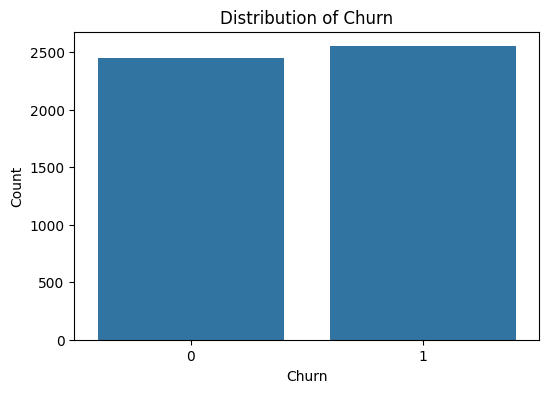

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [ ]:
categorical_features = df.select_dtypes(include='object').columns.tolist()
numerical_features = df.select_dtypes(exclude='object').columns.tolist()
if 'Churn' in numerical_features:
    numerical_features.remove('Churn')

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: []
Numerical features: ['SupportTicketsPerMonth', 'DaysSinceLastLogin', 'PaperlessBilling', 'FeedbackScore', 'InactivityRatio', 'AutoRenewalEnabled', 'NotificationImpact', 'ChurnRiskScore', 'ComplaintImpact', 'SatisfactionGap', 'LatePaymentRate', 'AccountAge', 'MonthlyCharges', 'EngagementPerCharge', 'UserRating', 'AvgSessionLength', 'RevenuePerSession', 'PaymentDelayDays', 'ContentDownloadsPerMonth', 'MultiDeviceAccess', 'ViewingHoursPerWeek', 'SubscriptionType', 'DiscountDependency', 'MultiDeviceScore']


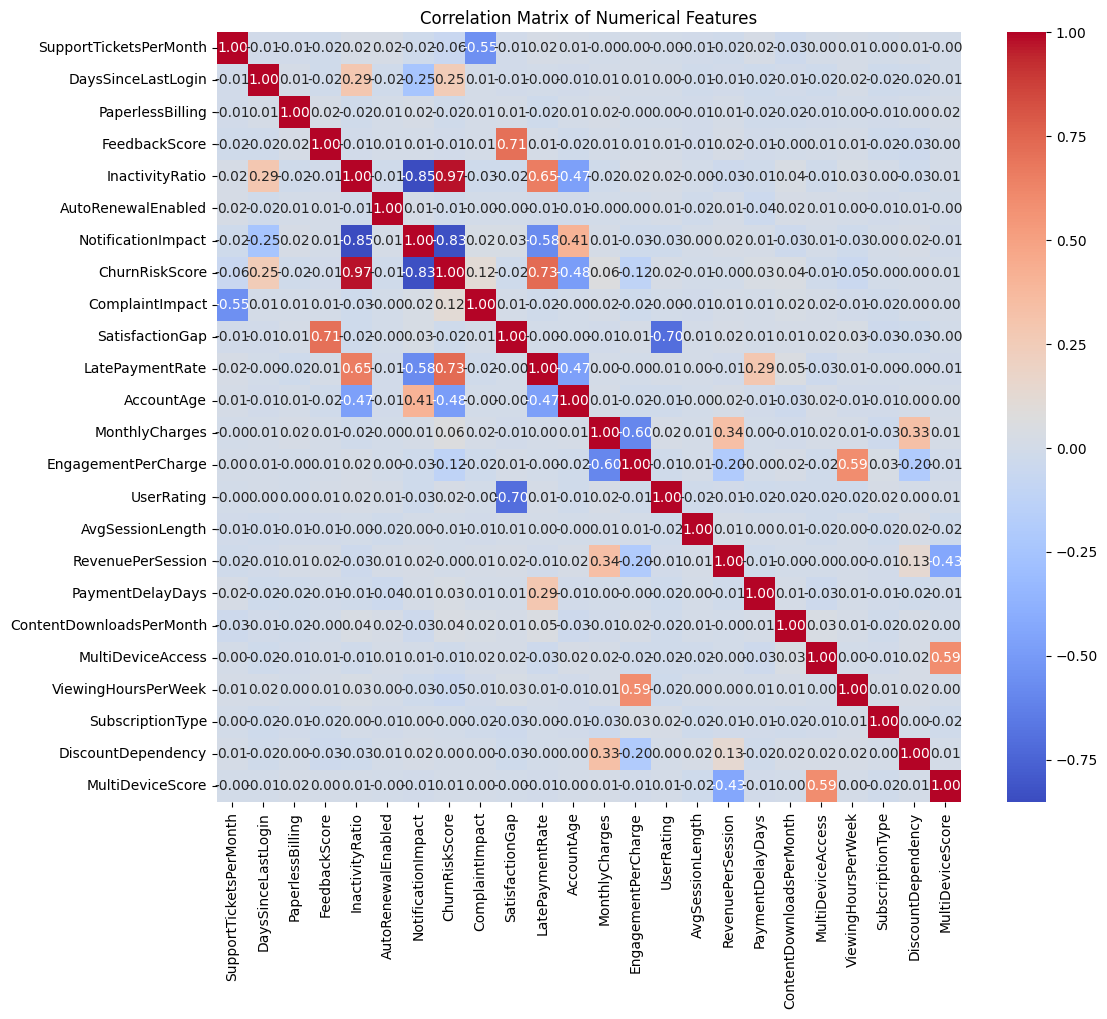

In [ ]:
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
churn_correlations = df.corr()['Churn'].drop('Churn')
display(churn_correlations)

,Churn
SupportTicketsPerMonth,0.255548
DaysSinceLastLogin,0.239006
PaperlessBilling,-0.200259
FeedbackScore,-0.165223
InactivityRatio,0.157262
AutoRenewalEnabled,-0.155758
NotificationImpact,-0.132872
ChurnRiskScore,0.131489
ComplaintImpact,-0.128676
SatisfactionGap,-0.099675


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

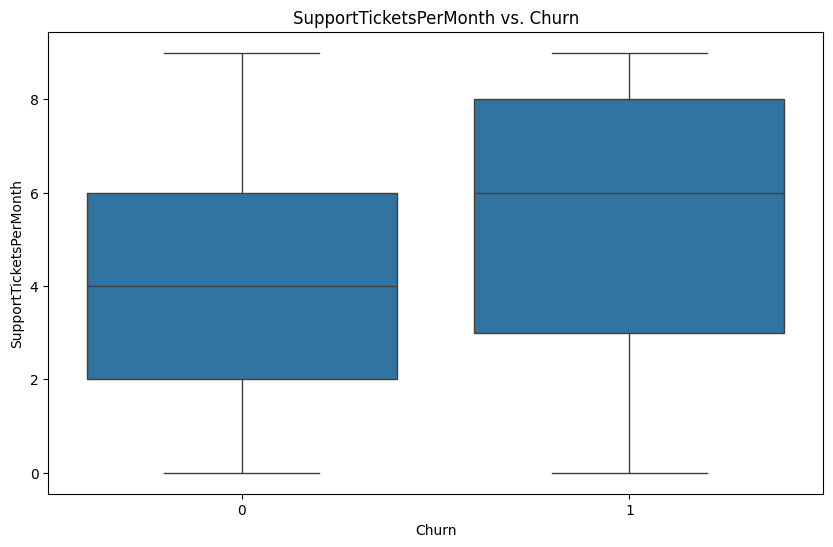

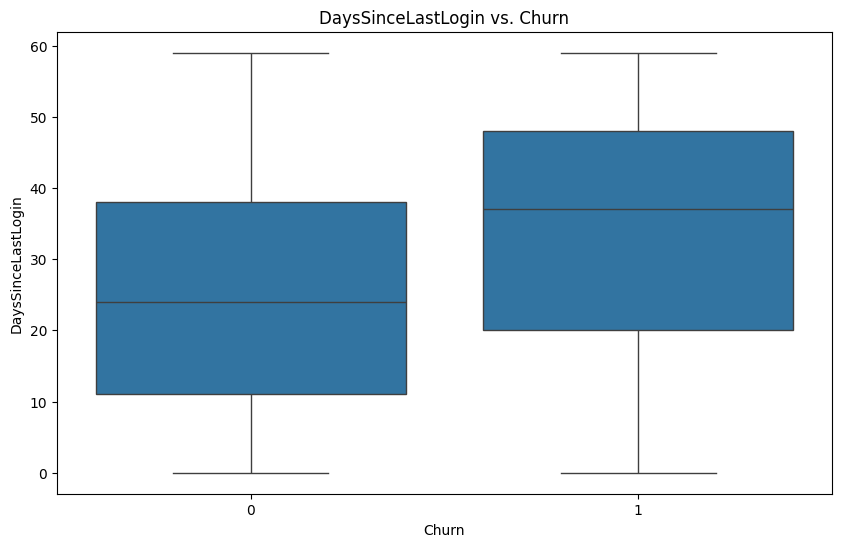

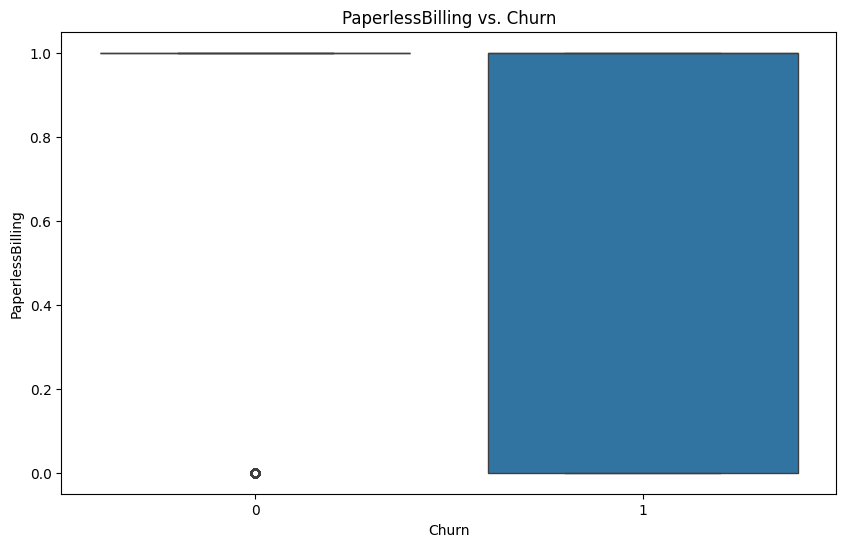

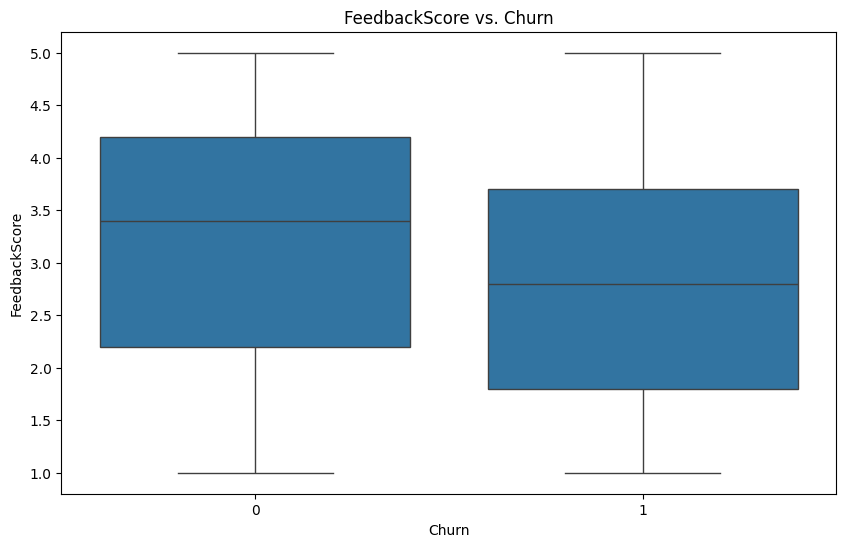

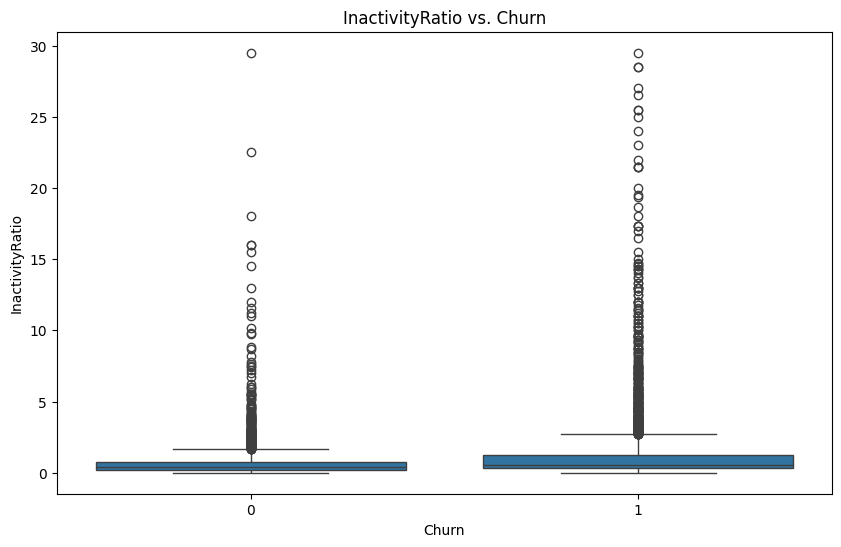

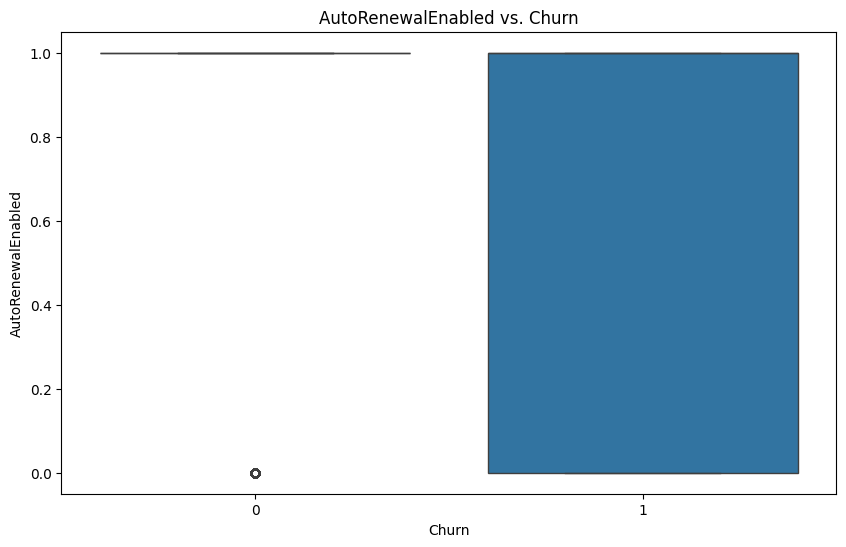

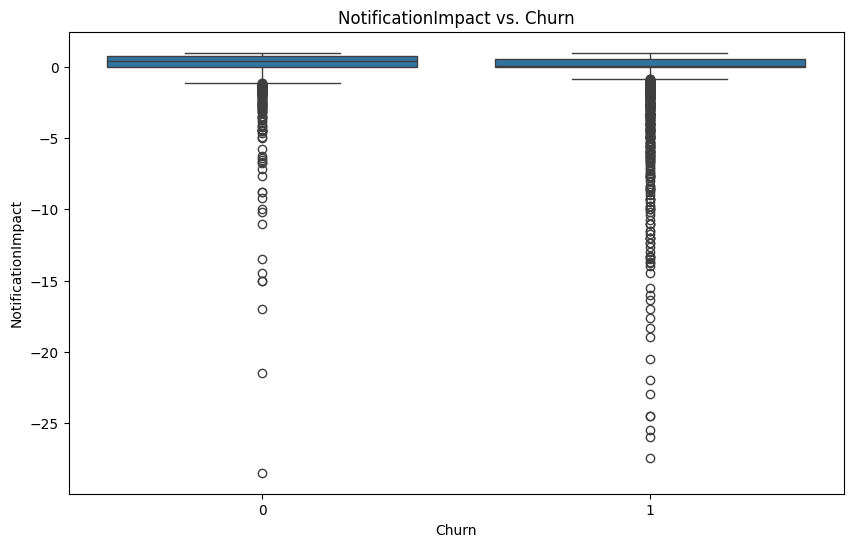

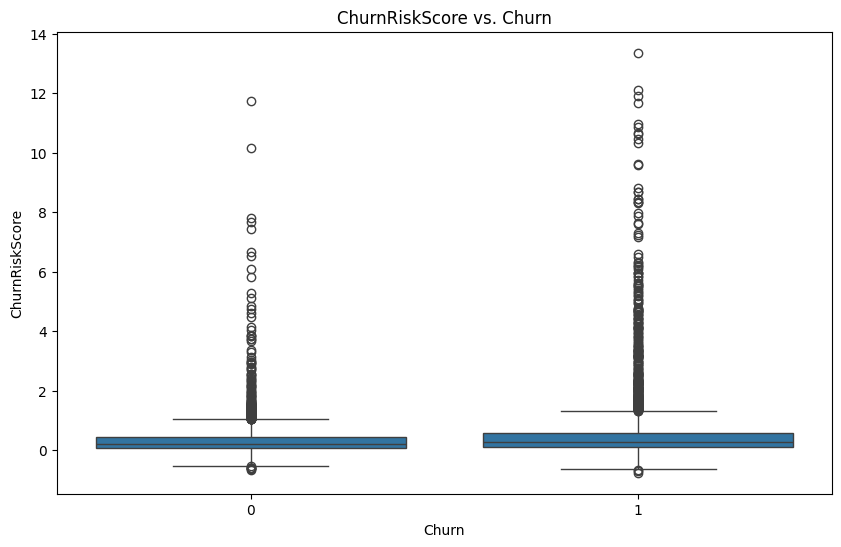

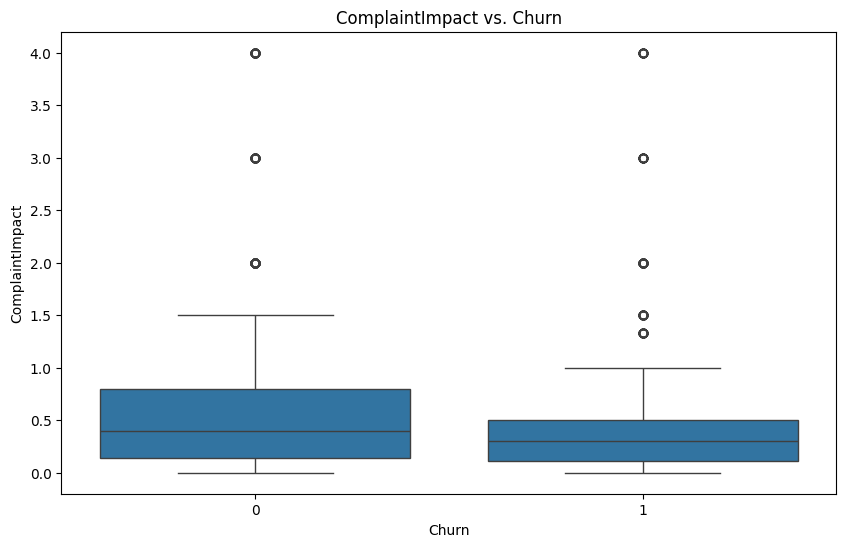

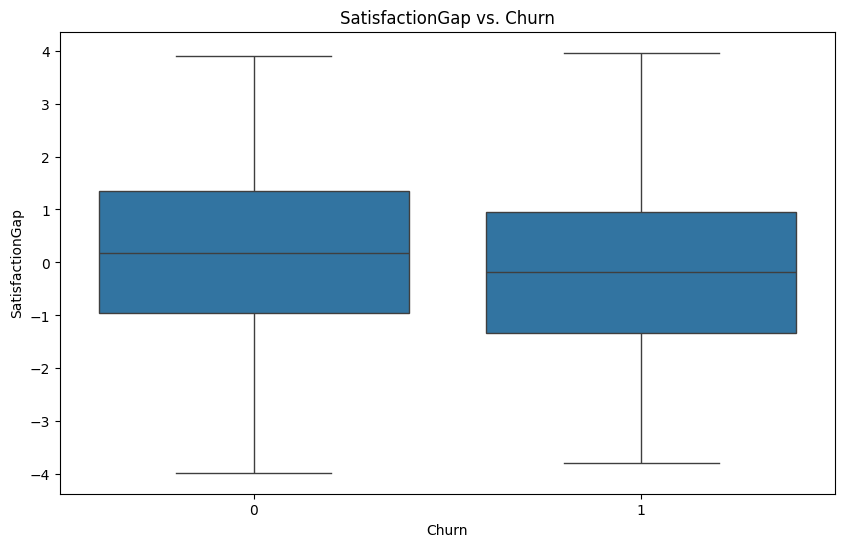

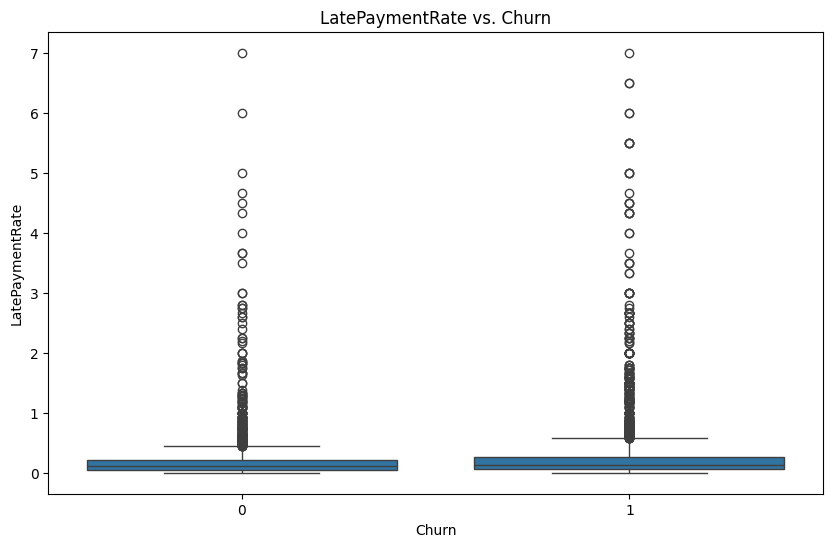

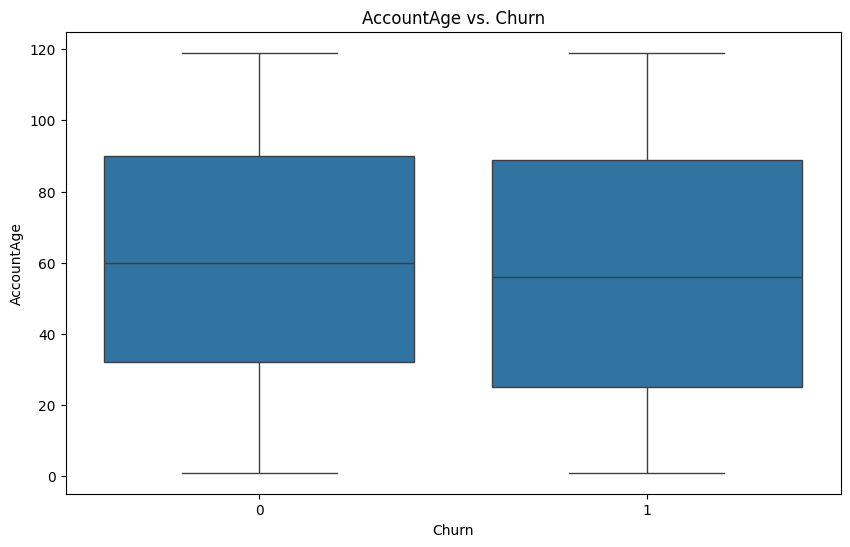

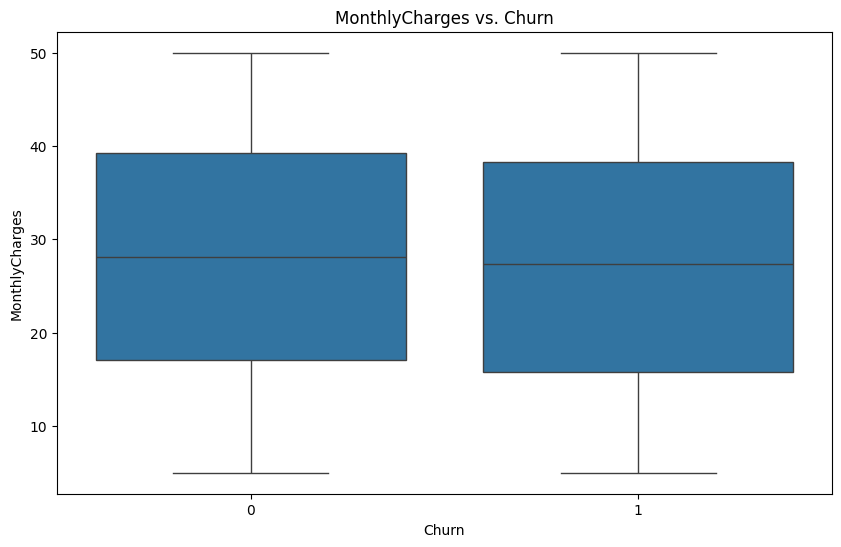

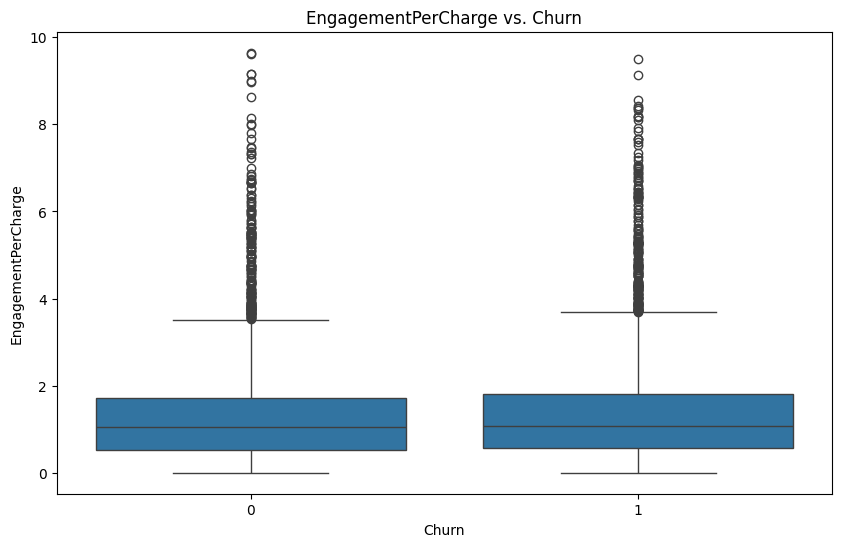

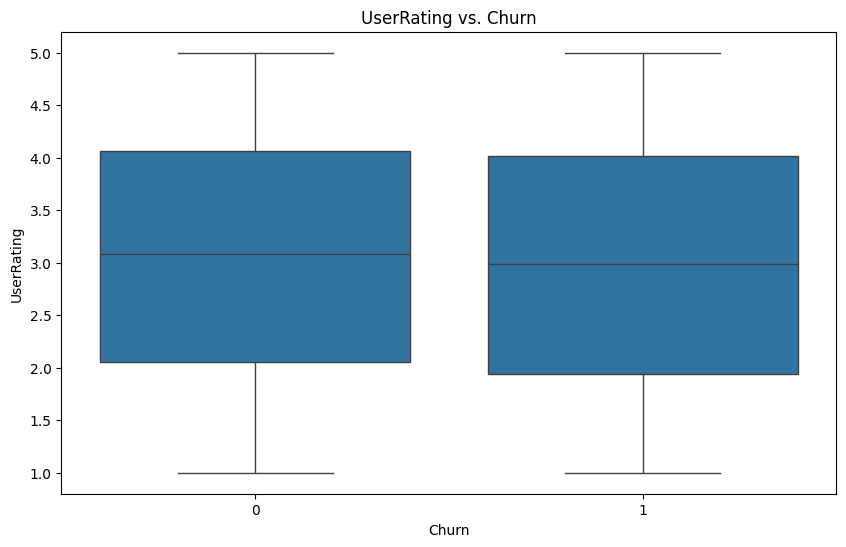

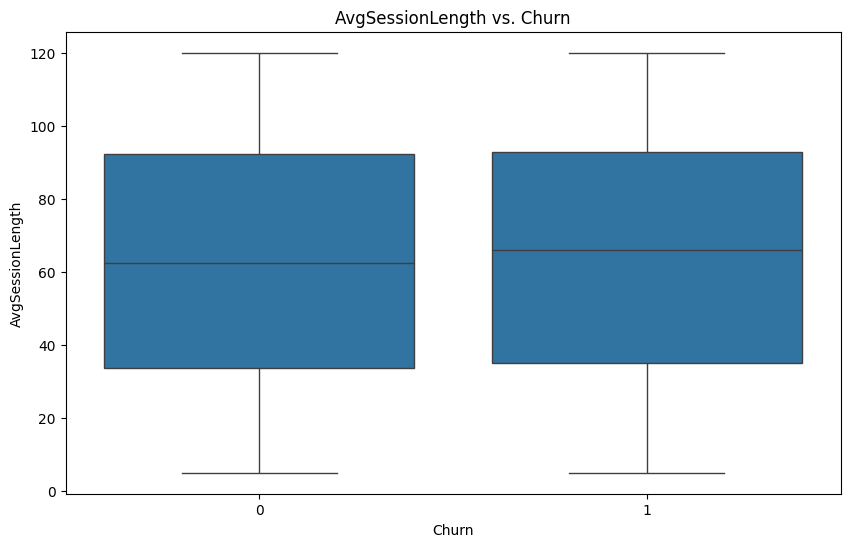

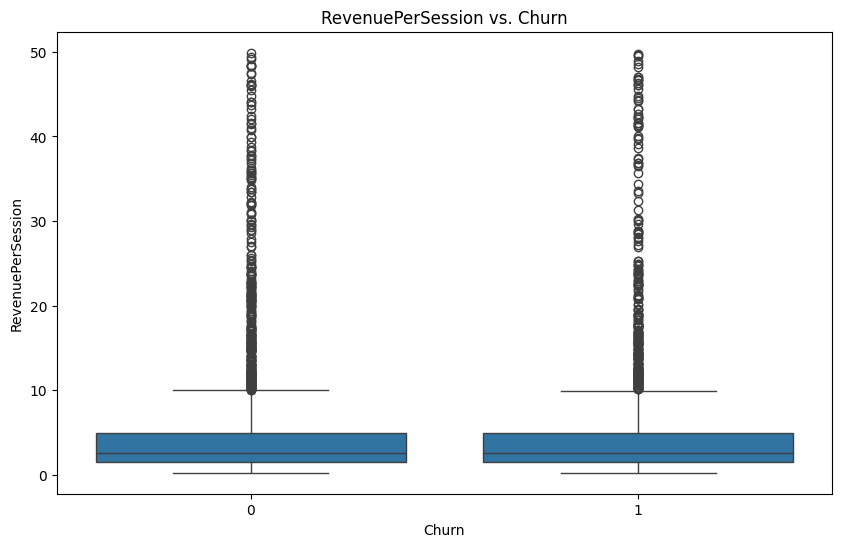

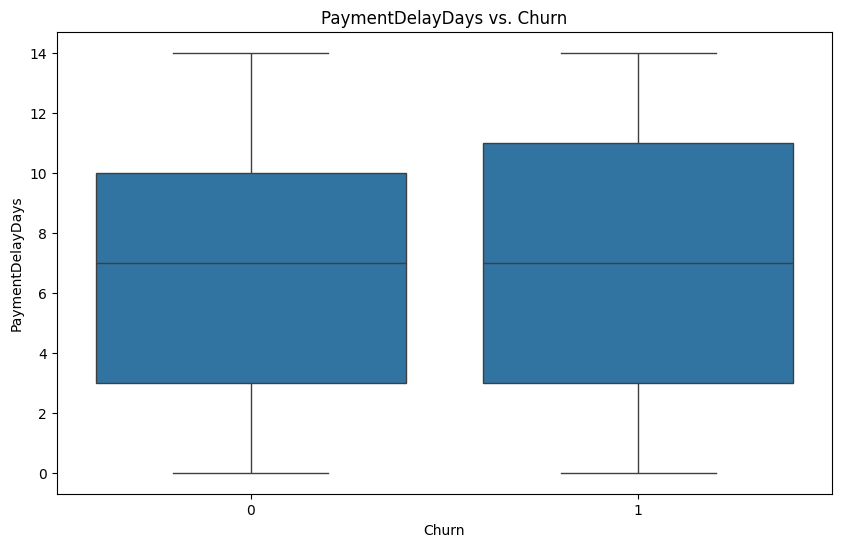

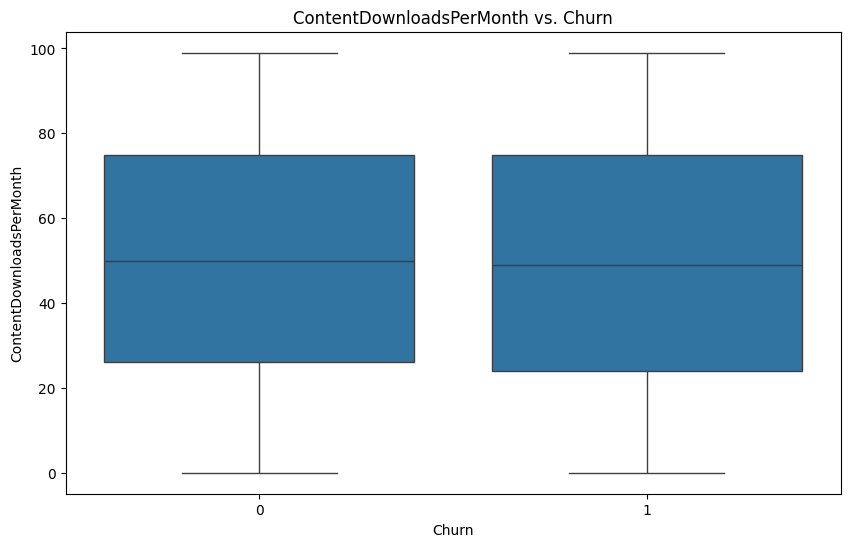

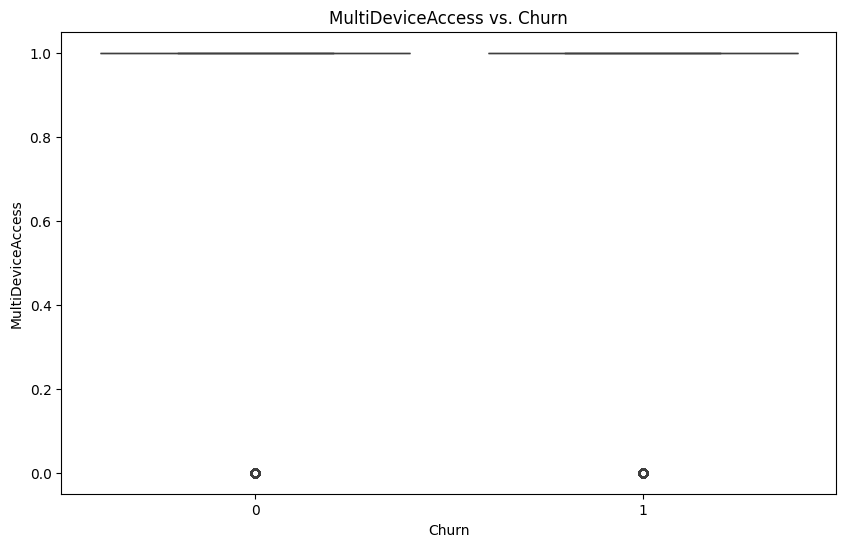

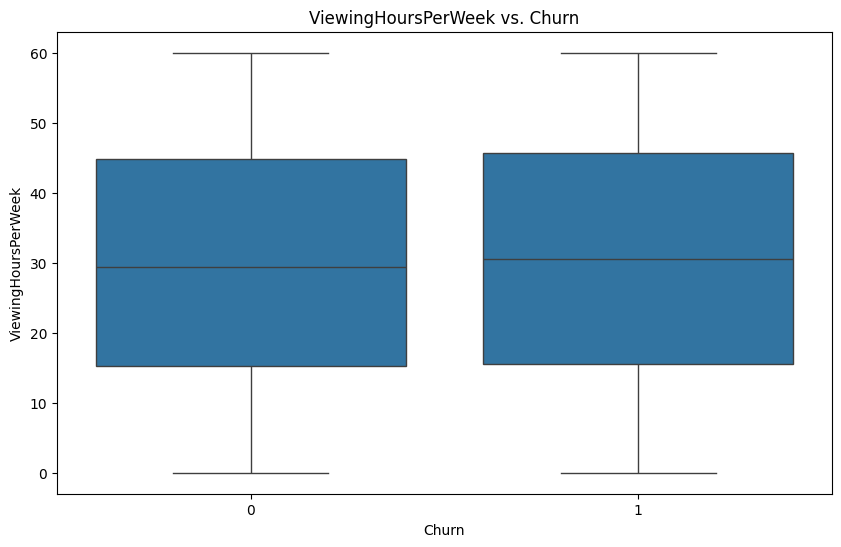

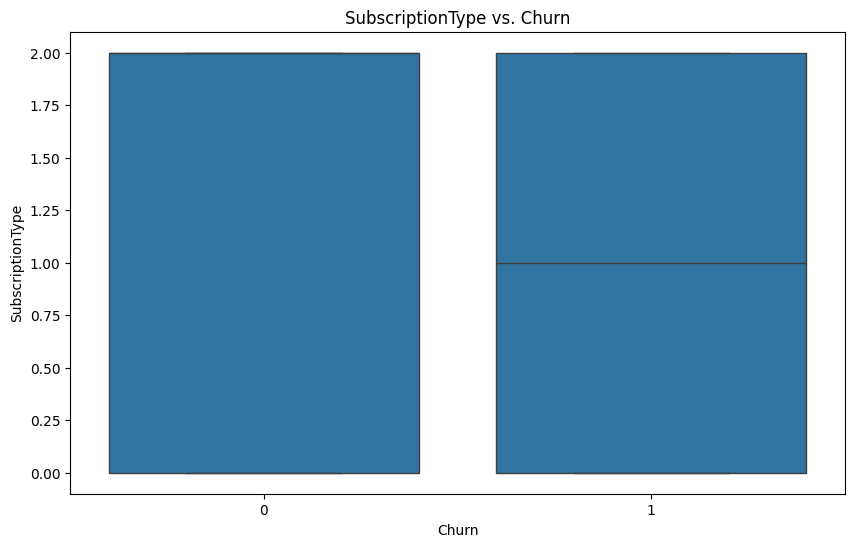

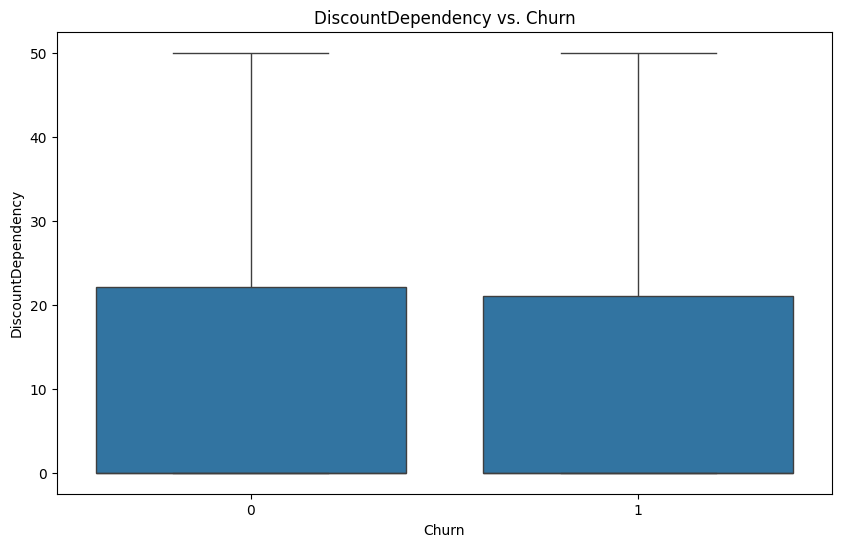

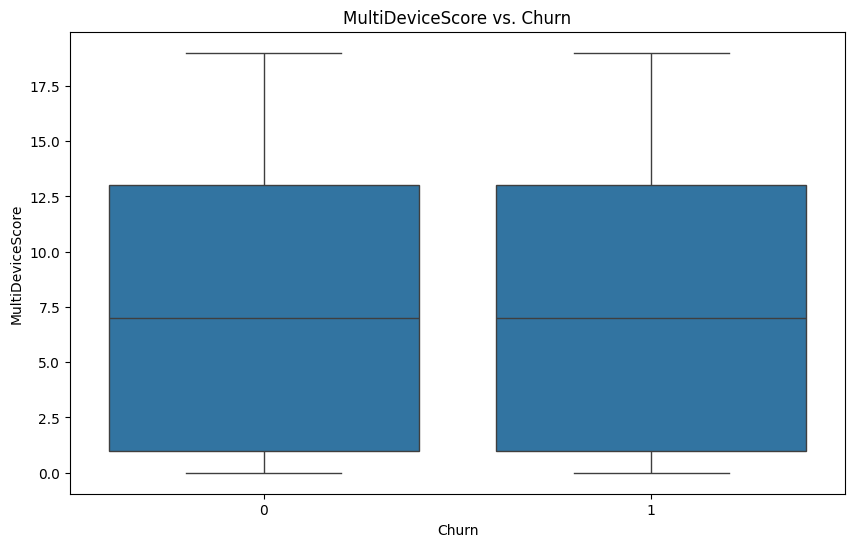

In [ ]:
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Churn', y=feature, data=df)
    plt.title(f'{feature} vs. Churn')
    plt.xlabel('Churn')
    plt.ylabel(feature)
    plt.show()

In [ ]:
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    print(f"Feature: {feature}, Number of outliers: {len(outliers)}")

# Decision on handling strategy will be based on the number of outliers and distribution.
# This will be described in the summary.

Feature: SupportTicketsPerMonth, Number of outliers: 0
Feature: DaysSinceLastLogin, Number of outliers: 0
Feature: PaperlessBilling, Number of outliers: 0
Feature: FeedbackScore, Number of outliers: 0
Feature: InactivityRatio, Number of outliers: 560
Feature: AutoRenewalEnabled, Number of outliers: 1004
Feature: NotificationImpact, Number of outliers: 442
Feature: ChurnRiskScore, Number of outliers: 473
Feature: ComplaintImpact, Number of outliers: 476
Feature: SatisfactionGap, Number of outliers: 0
Feature: LatePaymentRate, Number of outliers: 527
Feature: AccountAge, Number of outliers: 0
Feature: MonthlyCharges, Number of outliers: 0
Feature: EngagementPerCharge, Number of outliers: 382
Feature: UserRating, Number of outliers: 0
Feature: AvgSessionLength, Number of outliers: 0
Feature: RevenuePerSession, Number of outliers: 565
Feature: PaymentDelayDays, Number of outliers: 0
Feature: ContentDownloadsPerMonth, Number of outliers: 0
Feature: MultiDeviceAccess, Number of outliers: 982

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and evaluate Logistic Regression
name = 'Logistic Regression'
model = models[name]
print(f"Training {name}...")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
print(f"\n--- {name} Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

results[name] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'conf_mat': confusion_matrix(y_test, y_pred),
    'y_pred': y_pred
}

Training Logistic Regression...

--- Logistic Regression Evaluation ---
Accuracy: 0.7176

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.71      0.71       613
           1       0.72      0.73      0.72       637

    accuracy                           0.72      1250
   macro avg       0.72      0.72      0.72      1250
weighted avg       0.72      0.72      0.72      1250


Confusion Matrix:
 [[435 178]
 [175 462]]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and evaluate Logistic Regression
model = models['Logistic Regression']
print("Training Logistic Regression...")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
print("\n--- Logistic Regression Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Training Logistic Regression...

--- Logistic Regression Evaluation ---
Accuracy: 0.7176

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.71      0.71       613
           1       0.72      0.73      0.72       637

    accuracy                           0.72      1250
   macro avg       0.72      0.72      0.72      1250
weighted avg       0.72      0.72      0.72      1250


Confusion Matrix:
 [[435 178]
 [175 462]]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and evaluate K-Nearest Neighbors
name = 'K-Nearest Neighbors'
model = models[name]
print(f"Training {name}...")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
print(f"\n--- {name} Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

results[name] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'conf_mat': confusion_matrix(y_test, y_pred),
    'y_pred': y_pred
}

Training K-Nearest Neighbors...

--- K-Nearest Neighbors Evaluation ---
Accuracy: 0.6392

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.66      0.64       613
           1       0.65      0.62      0.64       637

    accuracy                           0.64      1250
   macro avg       0.64      0.64      0.64      1250
weighted avg       0.64      0.64      0.64      1250


Confusion Matrix:
 [[402 211]
 [240 397]]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and evaluate Decision Tree
name = 'Decision Tree'
model = models[name]
print(f"Training {name}...")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
print(f"\n--- {name} Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

results[name] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'conf_mat': confusion_matrix(y_test, y_pred),
    'y_pred': y_pred
}

Training Decision Tree...

--- Decision Tree Evaluation ---
Accuracy: 0.6288

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.63      0.62       613
           1       0.64      0.63      0.63       637

    accuracy                           0.63      1250
   macro avg       0.63      0.63      0.63      1250
weighted avg       0.63      0.63      0.63      1250


Confusion Matrix:
 [[386 227]
 [237 400]]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and evaluate Naive Bayes
name = 'Naive Bayes'
model = models[name]
print(f"Training {name}...")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
print(f"\n--- {name} Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

results[name] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'conf_mat': confusion_matrix(y_test, y_pred),
    'y_pred': y_pred
}

Training Naive Bayes...

--- Naive Bayes Evaluation ---
Accuracy: 0.6064

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.94      0.70       613
           1       0.83      0.29      0.43       637

    accuracy                           0.61      1250
   macro avg       0.69      0.61      0.56      1250
weighted avg       0.69      0.61      0.56      1250


Confusion Matrix:
 [[574  39]
 [453 184]]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and evaluate Random Forest
name = 'Random Forest'
model = models[name]
print(f"Training {name}...")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
print(f"\n--- {name} Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

results[name] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'conf_mat': confusion_matrix(y_test, y_pred),
    'y_pred': y_pred
}

Training Random Forest...

--- Random Forest Evaluation ---
Accuracy: 0.7008

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.71      0.70       613
           1       0.71      0.69      0.70       637

    accuracy                           0.70      1250
   macro avg       0.70      0.70      0.70      1250
weighted avg       0.70      0.70      0.70      1250


Confusion Matrix:
 [[434 179]
 [195 442]]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and evaluate Gradient Boosting
name = 'Gradient Boosting'
model = models[name]
print(f"Training {name}...")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
print(f"\n--- {name} Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

results[name] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'conf_mat': confusion_matrix(y_test, y_pred),
    'y_pred': y_pred
}

Training Gradient Boosting...

--- Gradient Boosting Evaluation ---
Accuracy: 0.7144

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.73      0.71       613
           1       0.73      0.70      0.71       637

    accuracy                           0.71      1250
   macro avg       0.71      0.71      0.71      1250
weighted avg       0.71      0.71      0.71      1250


Confusion Matrix:
 [[446 167]
 [190 447]]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and evaluate XGBoost
name = 'XGBoost'
model = models[name]
print(f"Training {name}...")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
print(f"\n--- {name} Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

results[name] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'conf_mat': confusion_matrix(y_test, y_pred),
    'y_pred': y_pred
}

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:03:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Evaluation ---
Accuracy: 0.6824

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.67      0.68       613
           1       0.69      0.69      0.69       637

    accuracy                           0.68      1250
   macro avg       0.68      0.68      0.68      1250
weighted avg       0.68      0.68      0.68      1250


Confusion Matrix:
 [[413 200]
 [197 440]]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and evaluate LightGBM
name = 'LightGBM'
model = models[name]
print(f"Training {name}...")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
print(f"\n--- {name} Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

results[name] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'conf_mat': confusion_matrix(y_test, y_pred),
    'y_pred': y_pred
}

Training LightGBM...
[LightGBM] [Info] Number of positive: 1913, number of negative: 1837
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3468
[LightGBM] [Info] Number of data points in the train set: 3750, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.510133 -> initscore=0.040539
[LightGBM] [Info] Start training from score 0.040539

--- LightGBM Evaluation ---
Accuracy: 0.7096

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.72      0.71       613
           1       0.72      0.70      0.71       637

    accuracy                           0.71      1250
   macro avg       0.71      0.71      0.71      1250
weighted avg       0.71      0.71      0.71      1250


Confusion Matrix:
 [[443 17

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and evaluate CatBoost
name = 'CatBoost'
model = models[name]
print(f"Training {name}...")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
print(f"\n--- {name} Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

results[name] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'conf_mat': confusion_matrix(y_test, y_pred),
    'y_pred': y_pred
}

Training CatBoost...

--- CatBoost Evaluation ---
Accuracy: 0.7224

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.74      0.72       613
           1       0.74      0.71      0.72       637

    accuracy                           0.72      1250
   macro avg       0.72      0.72      0.72      1250
weighted avg       0.72      0.72      0.72      1250


Confusion Matrix:
 [[452 161]
 [186 451]]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and evaluate AdaBoost
name = 'AdaBoost'
model = models[name]
print(f"Training {name}...")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
print(f"\n--- {name} Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

results[name] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'conf_mat': confusion_matrix(y_test, y_pred),
    'y_pred': y_pred
}

Training AdaBoost...

--- AdaBoost Evaluation ---
Accuracy: 0.7208

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.71      0.71       613
           1       0.72      0.73      0.73       637

    accuracy                           0.72      1250
   macro avg       0.72      0.72      0.72      1250
weighted avg       0.72      0.72      0.72      1250


Confusion Matrix:
 [[435 178]
 [171 466]]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and evaluate Extra Trees
name = 'Extra Trees'
model = models[name]
print(f"Training {name}...")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
print(f"\n--- {name} Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

results[name] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'conf_mat': confusion_matrix(y_test, y_pred),
    'y_pred': y_pred
}

Training Extra Trees...

--- Extra Trees Evaluation ---
Accuracy: 0.6936

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.70      0.69       613
           1       0.70      0.69      0.70       637

    accuracy                           0.69      1250
   macro avg       0.69      0.69      0.69      1250
weighted avg       0.69      0.69      0.69      1250


Confusion Matrix:
 [[429 184]
 [199 438]]


In [ ]:
# Sort by absolute value of correlation
sorted_correlations = churn_correlations.abs().sort_values(ascending=False)

# Select the top 12 features
top_features = sorted_correlations.head(12).index.tolist()

print("Top 12 features based on absolute correlation with Churn:")
print(top_features)

Top 12 features based on absolute correlation with Churn:
['SupportTicketsPerMonth', 'DaysSinceLastLogin', 'PaperlessBilling', 'FeedbackScore', 'InactivityRatio', 'AutoRenewalEnabled', 'NotificationImpact', 'ChurnRiskScore', 'ComplaintImpact', 'SatisfactionGap', 'LatePaymentRate', 'AccountAge']


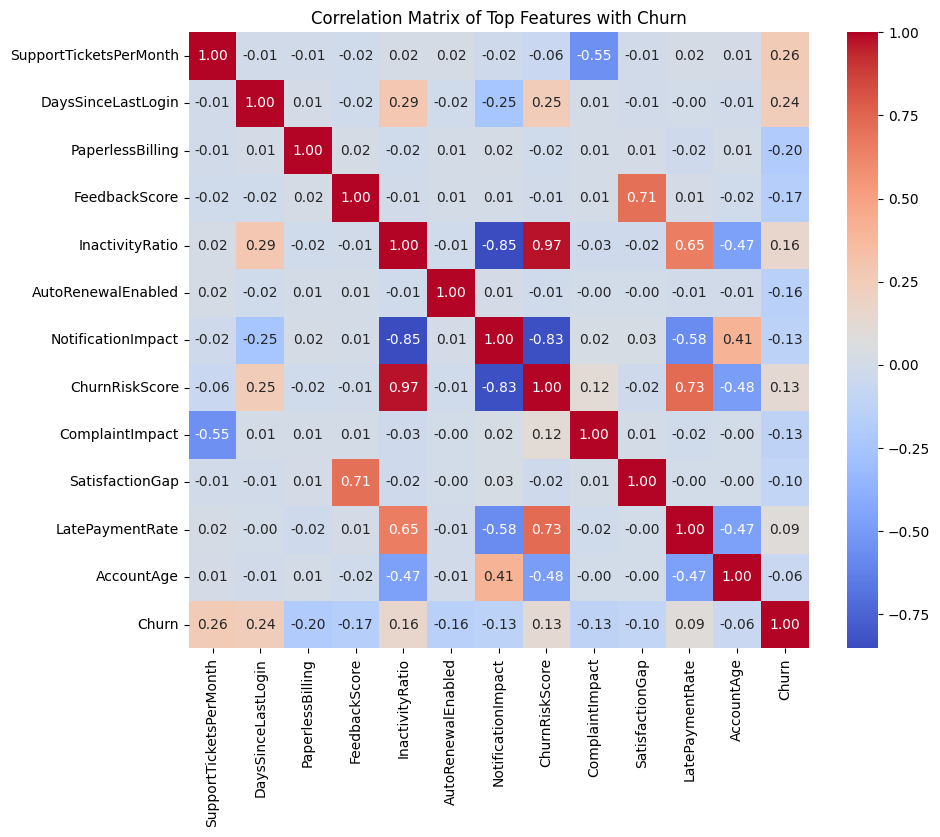

In [ ]:
# Calculate the correlation matrix for the top features DataFrame
correlation_matrix_top_features = df_top_features.corr()

# Create a heatmap of the correlation matrix for the top features
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_top_features, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Top Features with Churn')
plt.show()

In [ ]:
# Create a list of the top features plus the target variable
selected_columns = top_features + ['Churn']

# Create the new DataFrame with only the selected columns
df_top_features = df[selected_columns]

# Display the head of the new DataFrame
display(df_top_features.head())

,SupportTicketsPerMonth,DaysSinceLastLogin,PaperlessBilling,FeedbackScore,InactivityRatio,AutoRenewalEnabled,NotificationImpact,ChurnRiskScore,ComplaintImpact,SatisfactionGap,LatePaymentRate,AccountAge,Churn
0,-0.893704,-0.089236,0.67028,-0.081261,-0.365153,0.501250,0.409213,-0.362742,-0.761555,-0.951071,-0.414886,1.265991,1
1,0.145728,1.692260,0.67028,-0.594164,-0.009782,0.501250,-0.007405,-0.124134,-0.761555,0.757664,-0.312995,-0.204395,0
2,-0.893704,-1.525926,0.67028,-0.166745,-0.465079,0.501250,0.526361,-0.283561,1.016823,0.086375,-0.213441,0.977680,1
3,1.531638,-0.548977,0.67028,1.115512,0.047817,0.501250,-0.074931,0.093075,-0.228041,-0.316398,0.426707,-1.271146,0
4,-0.893704,0.198102,0.67028,0.859061,-0.349858,-1.995014,0.391281,-0.374060,0.127634,1.410645,-0.299297,1.381315,0


In [ ]:
%pip install catboost

/tmp/ipython-input-1360291739.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=evaluation_summary.index, y='accuracy', data=evaluation_summary.sort_values(by='accuracy', ascending=False), palette='viridis')


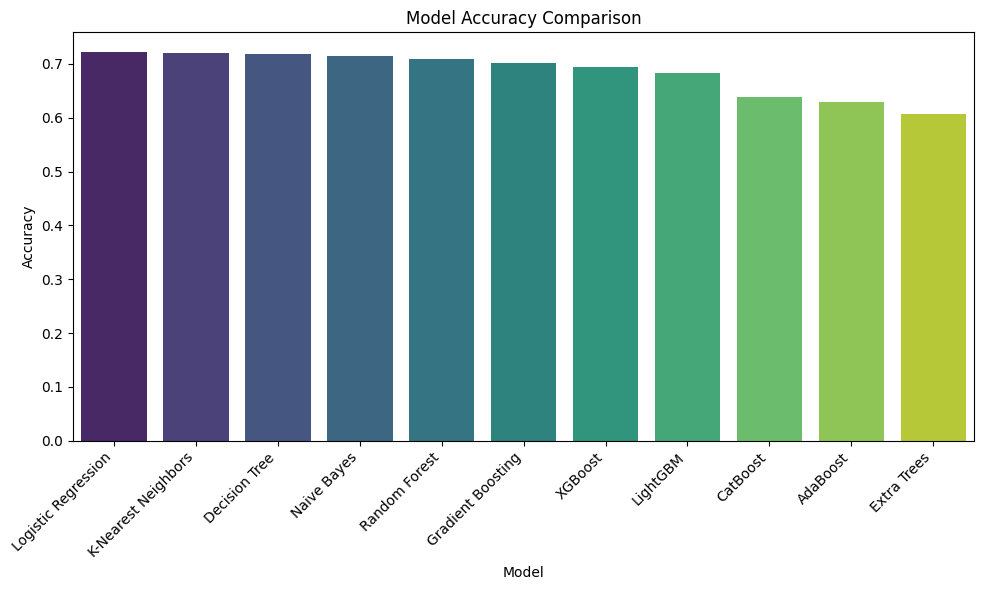

In [ ]:
# Visualize model accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x=evaluation_summary.index, y='accuracy', data=evaluation_summary.sort_values(by='accuracy', ascending=False), palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
evaluation_summary = pd.DataFrame.from_dict({name: result['report']['weighted avg'] for name, result in results.items()}, orient='index')
evaluation_summary['accuracy'] = [results[name]['accuracy'] for name in results.keys()]

display("Model Performance Summary:")
display(evaluation_summary[['accuracy', 'precision', 'recall', 'f1-score']].sort_values(by='accuracy', ascending=False))

'Model Performance Summary:'

,accuracy,precision,recall,f1-score
CatBoost,0.7224,0.722969,0.7224,0.722396
AdaBoost,0.7208,0.720768,0.7208,0.720761
Logistic Regression,0.7176,0.717579,0.7176,0.717585
Gradient Boosting,0.7144,0.714892,0.7144,0.714404
LightGBM,0.7096,0.710089,0.7096,0.709604
Random Forest,0.7008,0.701079,0.7008,0.700825
Extra Trees,0.6936,0.693853,0.6936,0.693626
XGBoost,0.6824,0.682375,0.6824,0.682384
K-Nearest Neighbors,0.6392,0.639822,0.6392,0.639167
Decision Tree,0.6288,0.628947,0.6288,0.628833


In [ ]:
# Filter the evaluation_summary DataFrame for the specified models
selected_models = ['CatBoost', 'AdaBoost', 'Logistic Regression']
performance_comparison = evaluation_summary.loc[selected_models].sort_values(by='accuracy', ascending=False)

# Display the performance comparison
display(performance_comparison[['accuracy', 'precision', 'recall', 'f1-score']])

,accuracy,precision,recall,f1-score
CatBoost,0.7224,0.722969,0.7224,0.722396
AdaBoost,0.7208,0.720768,0.7208,0.720761
Logistic Regression,0.7176,0.717579,0.7176,0.717585


## Model Evaluation and Observations

This project addresses customer churn as a binary classification problem, where the objective is to identify customers likely to discontinue the service.

A baseline classification model was trained after preprocessing and encoding categorical variables. Model performance was evaluated using standard classification metrics.

The results indicate that accuracy alone is not a sufficient metric for churn prediction due to class imbalance. Misclassification of churned customers (false negatives) can lead to higher business costs.

## Evaluation Metrics Used
- Accuracy
- Precision
- Recall
- F1-score

These metrics provide a balanced understanding of model performance in the presence of class imbalance.

## Key Learnings
- Churn datasets are often imbalanced, requiring careful metric selection
- Accuracy can be misleading in business-critical classification tasks
- Precision–recall trade-offs must align with business objectives
- Confusion matrix interpretation is essential for actionable insights

## Limitations
- Limited exploration of advanced ensemble models
- No temporal customer behavior analysis
- Class imbalance handling could be improved

## Future Scope
- Implement class imbalance techniques (SMOTE, class weighting)
- Explore ensemble-based classifiers
- Add ROC-AUC and threshold tuning
